# GPU essentials: what a GPU is, and why climate models use them

*The mental model — loops, threads, saturation — and one portable kernel.*

The realistic simulations later this week — a global ocean, a coupled ocean–sea ice Arctic — do not run
on a laptop: they run on **GPUs**. This notebook builds the *mental model* you need to read a model
configuration and understand why it asks for `architecture = GPU()`, and when that choice pays off. We
are deliberately *not* teaching GPU programming in depth — we want intuition, with just enough runnable
code to watch the ideas move.

Everything falls back to the CPU, so the notebook runs top-to-bottom on any laptop. If a GPU is present
— NVIDIA through CUDA, or an Apple chip through Metal — the same cells use it.

In [1]:
using CairoMakie, BenchmarkTools
using Base.Threads
using CUDA
using Metal
using KernelAbstractions
import KernelAbstractions: @kernel, @index, get_backend, synchronize

## Why a GPU? two different shapes of hardware

A CPU and a GPU answer two different questions. A **CPU** has a handful of fast, complex cores built to finish *one* chain of instructions as quickly as possible — each clever and quick. A **GPU** has *thousands* of simple, slower cores built to do the *same* operation on *mountains* of data at once — an army of students, each doing a little, all in step.

| | CPU | GPU |
|---|---|---|
| cores | a few (tens), fast | thousands, slow |
| optimized for | latency (one task, fast) | throughput (a million tasks) |
| best at | branchy, sequential logic | the same operation over a huge array |
| memory | large, deep caches | smaller, very high bandwidth |

The price of that throughput: the cores run in lockstep (so branches that diverge are expensive), the
data must be *copied* to the device first, and the win appears only when there is enough parallel work to
keep the army busy. A climate model — the same stencil applied to every cell of a huge grid — is almost
the perfect fit.

## What is climate modelling, really? Loops

Underneath the physics, a climate model is a set of **loops over the grid**. Every time step it walks across
every cell and does the same calculation there — the density from temperature and salinity, an update to a
velocity, the mixing of a tracer. Millions of cells, the same few lines, again and again. Here is one such
loop — the seawater density at every cell:

In [5]:
# seawater density from temperature θ (°C) and salinity s (psu)
seawater_density(θ, s) = 999.8 + 0.802s - 0.2θ - 0.0057θ^2 + 0.00004θ^3 + 0.00067θ*s

function density!(ρ, T, S)
    for i in eachindex(ρ)
        @inbounds ρ[i] = seawater_density(T[i], S[i])
    end
    return ρ
end

n = 10_000_000                          # ten million cells
T = 30 .* rand(n); S = 30 .+ 6 .* rand(n); ρ = zeros(n)
@btime density!($ρ, $T, $S);

  3.778 ms (0 allocations: 0 bytes)


Now look closely: cell `i` does not depend on cell `i-1`. Each density comes from *that* cell's own
temperature and salinity — the iterations are **independent**. So why do them one after another? We can do
them *together*.

In [4]:
function density_threaded!(ρ, T, S)
    @threads for i in eachindex(ρ)          # share the cells across all the workers
        @inbounds ρ[i] = seawater_density(T[i], S[i])
    end
    return ρ
end

@info "this session has $(nthreads()) worker thread(s)"
@btime density_threaded!($ρ, $T, $S);

[ Info: this session has 6 worker thread(s)


  859.042 μs (32 allocations: 2.27 KiB)


Faster — the independent cells were split across the CPU's handful of workers, all running at once. Now
picture this *on steroids*: not a handful of workers, but **thousands**. That is a GPU — the same independent
loop, the same calculation at every cell, spread across thousands of cores at the same time. That is exactly
why climate models run on GPUs.

## Choosing a device, once

A model selects its hardware in a single place; we do the same. Prefer a CUDA GPU, then an Apple GPU via
Metal, otherwise the CPU. GPUs compute in **single precision**, so device arrays are `Float32`.

In [7]:
backend, device_name = if CUDA.functional()
    CUDA.CUDABackend(), "CUDA GPU"
elseif Metal.functional()
    Metal.MetalBackend(), "Apple GPU (Metal)"
else
    KernelAbstractions.CPU(), "CPU"
end

@info "Running on the $device_name"

[ Info: Running on the Apple GPU (Metal)


## Array programming: parallelism for free

You rarely start by writing kernels. A GPU array is a *different type* that supports the *same*
operations as an ordinary one — so once the data is on the device, broadcasts and reductions already run
there, in parallel, with no kernel in sight. Move a field across, then use the usual array syntax:

In [8]:
xₕ = randn(Float32, 512, 512)                          # a field on the host (CPU)
x  = KernelAbstractions.zeros(backend, Float32, 512, 512)
copyto!(x, xₕ)                                         # the same data, now on the device

∇²x = circshift(x, (1, 0)) .+ circshift(x, (-1, 0)) .+
      circshift(x, (0, 1)) .+ circshift(x, (0, -1)) .- 4 .* x   # a Laplacian stencil, run on the device
(sum(x), maximum(abs, ∇²x))                            # reductions run on the device too

(432.42072f0, 21.182657f0)

Not one line of that mentions threads or kernels — Julia's broadcasting (the dots) plus the GPU array
type did the parallelism. A great deal of model code is exactly this: fused broadcasts and reductions
over fields, fast on a GPU for free. Kernels, next, are the escape hatch — for the loop that *no* built-in
array operation expresses.

## Threads and blocks: a kernel is a loop over threads

This is the loop-split idea taken to the extreme. On a CPU you spread the loop across a handful of threads;
on a GPU you write the **body** of the loop *once* — a *kernel* — and the hardware runs one copy per
**thread**, thousands at a time, each on its own element:

```julia
for i in 1:N             #  ↔   i = @index(Global)         # the kernel is the *inside* of the loop;
    y[i] = a*x[i] + y[i] #           y[i] = a*x[i] + y[i]   # the hardware supplies the loop — one i per thread
end
```

Threads are organized into **blocks** (KernelAbstractions calls them *workgroups*) — the launch size,
say 256 threads each — which the hardware schedules across its cores:

```
  block 0                block 1                ...
  ┌────────────────────┐ ┌────────────────────┐
  │ t0 t1 t2 … t255    │ │ t0 t1 t2 … t255    │   each tₖ runs the kernel body on one element
  └────────────────────┘ └────────────────────┘
```

Here is `y = a·x + y` (a "saxpy") written as a kernel — the same per-element shape as the density loop,
now with one thread per element — using
[KernelAbstractions.jl](https://github.com/JuliaGPU/KernelAbstractions.jl):

In [22]:
@kernel function _saxpy!(y, a, x)
    i = @index(Global)                  # this thread's element — the loop index the hardware hands us
    @inbounds y[i] = a * x[i] + y[i]
end

function saxpy!(y, a, x)
    backend = get_backend(y)            # CPU(), CUDABackend(), or MetalBackend() — read off the data
    _saxpy!(backend, 256)(y, a, x; ndrange = length(y))   # 256 threads per block, length(y) total
    synchronize(backend)
    return y
end

saxpy! (generic function with 1 method)

On a plain CPU array it is just an (optionally multithreaded) loop:

In [10]:
let x = ones(Float32, 1000), y = ones(Float32, 1000)
    saxpy!(y, 2f0, x)
    y[1]                                # 2*1 + 1 = 3
end

3.0f0

## Saturation: a GPU needs enough work

Thousands of cores only help if there is enough work to spread across them. Below a certain size the
launch overhead dominates and most of the army stands idle; throughput climbs with the problem size and
then *saturates* at the hardware's ceiling. We measure it directly — elements updated per second by
`saxpy!` as the array grows — on the chosen device:

In [18]:
struct SimpleCPU end

function simple_saxpy!(y, a, x)
    for i in eachindex(x)
        @inbounds y[i] = 2.f0 * x[i] + y[i]
    end
end

function throughput(backend::SimpleCPU, n)
    x = zeros(Float32, n)
    y = zeros(Float32, n)
    t = @belapsed simple_saxpy!($y, 2f0, $x)
    return n / t
end

function throughput(backend, n)
    x = KernelAbstractions.zeros(backend, Float32, n); fill!(x, 1f0)
    y = KernelAbstractions.zeros(backend, Float32, n); fill!(y, 1f0)
    saxpy!(y, 2f0, x)                                    # warm up: compile the kernel
    t = @belapsed (saxpy!($y, 2f0, $x); synchronize($backend))
    return n / t                                         # elements per second
end

sizes       = [2^k for k in 10:2:24]                        # up to ~16 million elements
cpu_rates   = [throughput(KernelAbstractions.CPU(), n) for n in sizes]
naive_rates = [throughput(SimpleCPU(), n) for n in sizes]
gpu_rates   = backend isa KernelAbstractions.CPU ? nothing : [throughput(backend, n) for n in sizes]
nothing #hide

Plotting throughput against array size makes the saturation visible:

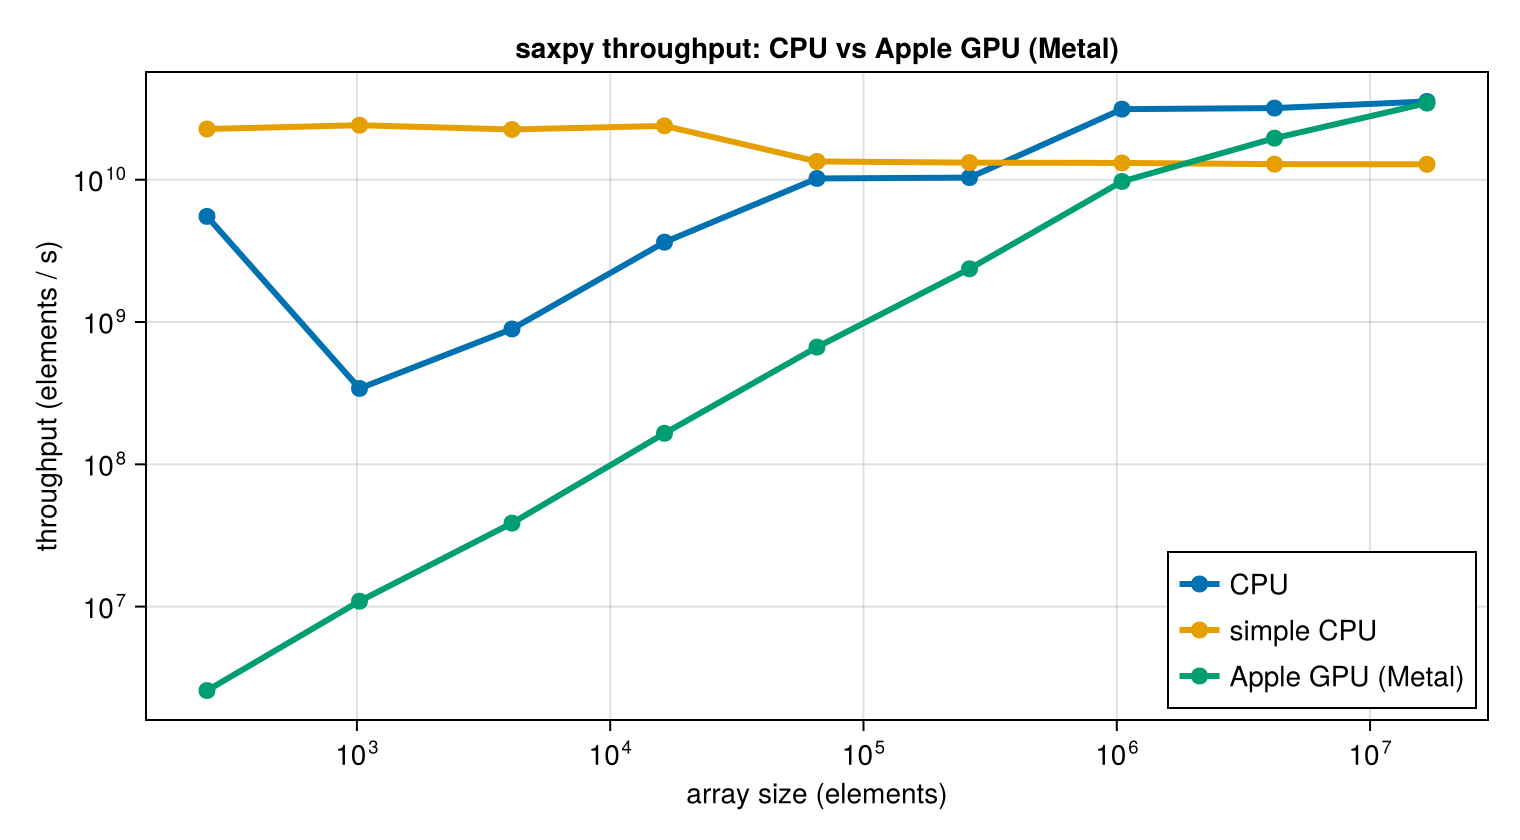

In [21]:
plot_title = gpu_rates === nothing ? "saxpy throughput (CPU only)" : "saxpy throughput: CPU vs $device_name"
fig = Figure(size = (760, 420))
ax = Axis(fig[1, 1]; xlabel = "array size (elements)", ylabel = "throughput (elements / s)",
          xscale = log10, yscale = log10, title = plot_title)
scatterlines!(ax, sizes, cpu_rates; linewidth = 3, markersize = 12, label = "CPU")
scatterlines!(ax, sizes, naive_rates; linewidth = 3, markersize = 12, label = "simple CPU")
gpu_rates === nothing || scatterlines!(ax, sizes, gpu_rates; linewidth = 3, markersize = 12, label = device_name)
axislegend(ax; position = :rb)
save("gpu_saturation.png", fig)
fig

The two curves tell the whole story. On a CPU throughput is fairly flat — a few cores hit their modest
peak almost at once, so the *smallest* arrays even run faster there. The GPU starts *below* the CPU, with
thousands of cores sitting idle, but as the arrays grow it climbs, crosses over, and pulls far ahead —
plateauing at a much higher ceiling once it saturates. The practical rule follows directly: **a GPU pays
off for large, parallel problems**; starved of work, it is genuinely slower than a CPU.

## One kernel, every device

Notice what did *not* change between a CPU run and a GPU run: `_saxpy!`. The same kernel body, the same
`saxpy!` launcher — only the array *type* differed, and `get_backend` read the device off it. This is
exactly how the models you will run are written: one set of kernels, dispatched onto whatever
`architecture` the configuration names —

```julia
architecture = CPU()      # develop and debug on a laptop
architecture = GPU()      # the identical model, now on the device
```

That is the takeaway. You will not *write* GPU code this week, but you now know what it is doing and why
it is there: thousands of lanes, fed enough data to stay busy, running the same loop body a CPU would —
just very many more of them, all at once.

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*